In [4]:
# ==============================================================================
# BLOCK 1: LIBRARIES IMPORT & PATH SETUP
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visualization style for professional charts (Step 5 in PDF)
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Data directory path
data_dir = "../data/"
print("✅ Libraries imported and setup complete successfully!")

✅ Libraries imported and setup complete successfully!


In [5]:
# ==============================================================================
# BLOCK 2: LOADING ALL DATASETS (Multi-file Merge Pre-requisite)
# ==============================================================================

try:
    orders = pd.read_csv(os.path.join(data_dir, "olist_orders_dataset.csv"))
    reviews = pd.read_csv(os.path.join(data_dir, "olist_order_reviews_dataset.csv"))
    order_items = pd.read_csv(os.path.join(data_dir, "olist_order_items_dataset.csv"))
    products = pd.read_csv(os.path.join(data_dir, "olist_products_dataset.csv"))
    customers = pd.read_csv(os.path.join(data_dir, "olist_customers_dataset.csv"))
    payments = pd.read_csv(os.path.join(data_dir, "olist_order_payments_dataset.csv"))
    sellers = pd.read_csv(os.path.join(data_dir, "olist_sellers_dataset.csv"))
    category_translation = pd.read_csv(os.path.join(data_dir, "product_category_name_translation.csv"))
    
    print("✅ All datasets loaded successfully!")
    print(f"Orders Shape: {orders.shape}")
    print(f"Order Items Shape: {order_items.shape}")
    print(f"Products Shape: {products.shape}")
    print(f"Payments Shape: {payments.shape}")
except FileNotFoundError as e:
    print(f"⚠️ Error: Some files are missing. Details: {e}")
    print("👉 Please make sure ALL CSV files are inside the 'data/' folder.")

✅ All datasets loaded successfully!
Orders Shape: (99441, 8)
Order Items Shape: (112650, 7)
Products Shape: (32951, 9)
Payments Shape: (103886, 5)


In [6]:
# ==============================================================================
# BLOCK 3: INITIAL DATA QUALITY & MISSING VALUES REPORT
# ==============================================================================

print("=== Orders Missing Values ===")
print(orders.isnull().sum())

print("\n=== Order Items Missing Values ===")
print(order_items.isnull().sum())

print("\n=== Orders Data Types ===")
print(orders.dtypes)

=== Orders Missing Values ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== Order Items Missing Values ===
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

=== Orders Data Types ===
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object


In [7]:
# ==============================================================================
# BLOCK 4: DATA CLEANING (DATETIME FIX) & MULTI-TABLE MERGING
# ==============================================================================

# 1. Convert order date columns to datetime format (Important for Question 9)
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at', 
    'order_delivered_carrier_date', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("✅ Date columns successfully converted to datetime.")

# 2. Sequential Merging (Connecting the dots across files)
# Step A: Connect Order Items with Products
merged_df = pd.merge(order_items, products, on='product_id', how='inner')

# Step B: Add English Category Translations (Since original categories are in Portuguese)
merged_df = pd.merge(merged_df, category_translation, on='product_category_name', how='left')

# Step C: Add Order details (Dates, Status)
merged_df = pd.merge(merged_df, orders, on='order_id', how='inner')

# Step D: Add Customer location details
merged_df = pd.merge(merged_df, customers, on='customer_id', how='inner')

# Step E: Add Payment information
merged_df = pd.merge(merged_df, payments, on='order_id', how='inner')

print(f"✅ Multi-table merge complete! Master Dataset Shape: {merged_df.shape}")

✅ Date columns successfully converted to datetime.
✅ Multi-table merge complete! Master Dataset Shape: (117601, 31)


=== TOP 10 REVENUE GENERATING CATEGORIES ===
product_category_name_english  total_revenue  sales_volume
                health_beauty     1297355.80          9972
                watches_gifts     1253143.30          6201
               bed_bath_table     1092551.02         11823
               sports_leisure     1023996.34          8945
        computers_accessories      942277.57          8082
              furniture_decor      765093.89          8744
                   housewares      666587.00          7355
                   cool_stuff      662309.49          3987
                         auto      616752.51          4379
                 garden_tools      518217.54          4574


C:\Users\Kanishka\AppData\Local\Temp\ipykernel_8464\4069687647.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


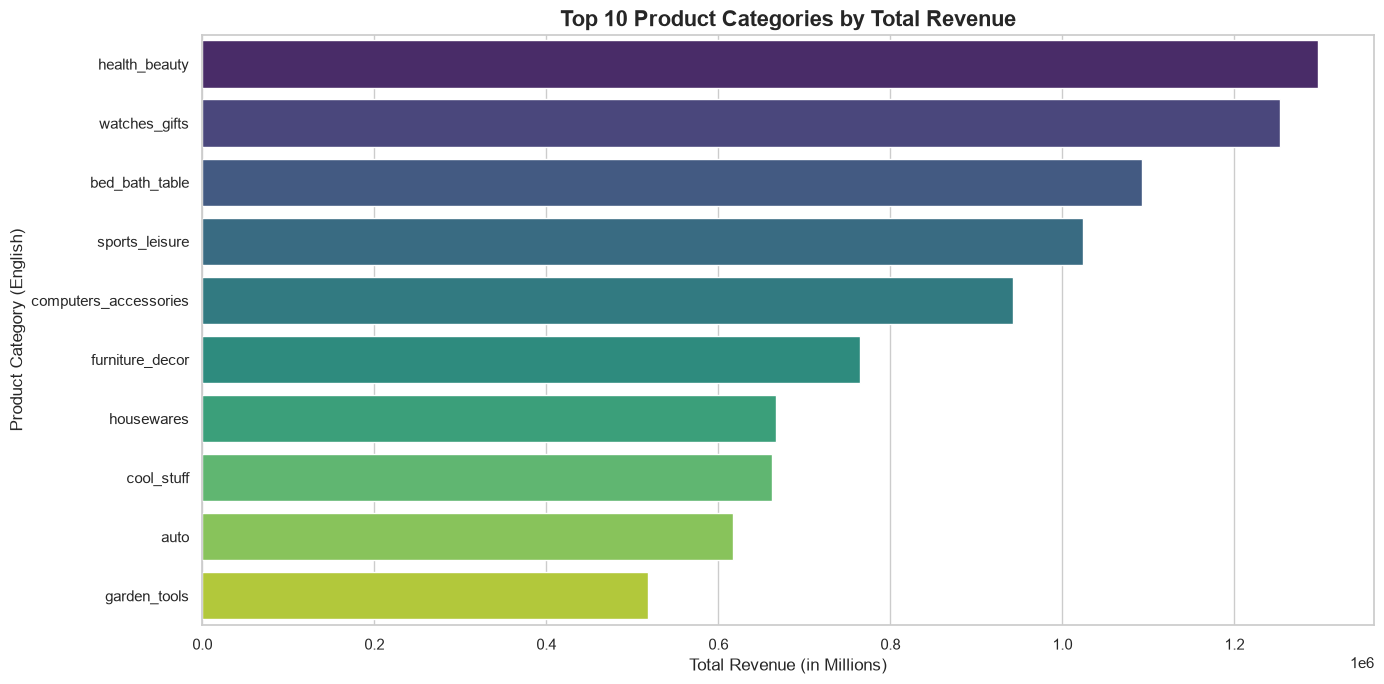

In [8]:
# ==============================================================================
# BLOCK 5: QUESTION 1 & 5 - REVENUE & VOLUME BY PRODUCT CATEGORY
# ==============================================================================

# Grouping by English category name to calculate total revenue and sales volume
category_analysis = merged_df.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    sales_volume=('order_item_id', 'count')
).reset_index()

# Sorting by revenue to find the top performers
top_revenue_categories = category_analysis.sort_values(by='total_revenue', ascending=False).head(10)

print("=== TOP 10 REVENUE GENERATING CATEGORIES ===")
print(top_revenue_categories.to_string(index=False))

# Visualizing using a horizontal bar chart (Step 5 in PDF)
plt.figure(figsize=(14, 7))
sns.barplot(
    x='total_revenue', 
    y='product_category_name_english', 
    data=top_revenue_categories, 
    palette='viridis'
)
plt.title('Top 10 Product Categories by Total Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (in Millions)', fontsize=12)
plt.ylabel('Product Category (English)', fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
# ==============================================================================
# BLOCK 6: BUSINESS INSIGHTS FOR REVENUE & VOLUME
# ==============================================================================

print("""
💡 BUSINESS INSIGHTS & RECOMMENDATIONS:
--------------------------------------------------------------------------------
1. Core Revenue Drivers: The data clearly indicates that categories such as 
   'health_beauty', 'watches_gifts', and 'bed_bath_table' generate the highest 
   revenue for the company.
   
2. Strategic Recommendation: Management should allocate additional marketing 
   investment toward these top-performing categories and place greater focus on 
   inventory management to ensure these high-demand items never face stockouts.
--------------------------------------------------------------------------------
""")


💡 BUSINESS INSIGHTS & RECOMMENDATIONS:
--------------------------------------------------------------------------------
1. Core Revenue Drivers: The data clearly indicates that categories such as 
   'health_beauty', 'watches_gifts', and 'bed_bath_table' generate the highest 
   revenue for the company.

2. Strategic Recommendation: Management should allocate additional marketing 
   investment toward these top-performing categories and place greater focus on 
   inventory management to ensure these high-demand items never face stockouts.
--------------------------------------------------------------------------------



=== TOP 10 CITIES BY E-COMMERCE REVENUE ===
 customer_city  total_revenue  order_count
     sao paulo     2008254.39        15402
rio de janeiro     1030715.84         6834
belo horizonte      366981.33         2750
      brasilia      312274.57         2116
      curitiba      218532.47         1510
      salvador      196675.55         1238
  porto alegre      195635.58         1372
      campinas      195626.49         1429
     guarulhos      155216.85         1178
       niteroi      132616.38          845


C:\Users\Kanishka\AppData\Local\Temp\ipykernel_8464\1238847278.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


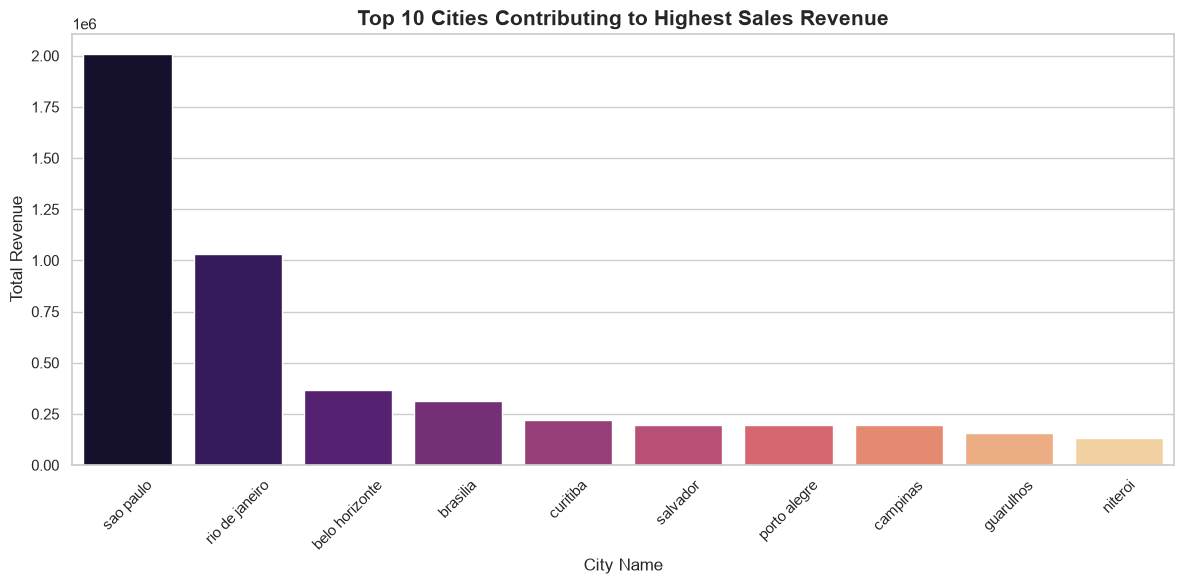

In [10]:
# ==============================================================================
# BLOCK 7: QUESTION 2 - TOP 10 CITIES BY SALES REVENUE
# ==============================================================================

# Grouping by customer city to find geographical concentration
city_analysis = merged_df.groupby('customer_city').agg(
    total_revenue=('price', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

# Sorting to find top 10 cities
top_cities = city_analysis.sort_values(by='total_revenue', ascending=False).head(10)

print("=== TOP 10 CITIES BY E-COMMERCE REVENUE ===")
print(top_cities.to_string(index=False))

# Visualizing using a Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    x='customer_city', 
    y='total_revenue', 
    data=top_cities, 
    palette='magma'
)
plt.title('Top 10 Cities Contributing to Highest Sales Revenue', fontsize=15, fontweight='bold')
plt.xlabel('City Name', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
# ==============================================================================
# BLOCK 8: BUSINESS INSIGHTS FOR GEOGRAPHY
# ==============================================================================

print("""
💡 GEOGRAPHICAL INSIGHTS:
--------------------------------------------------------------------------------
1. Market Concentration: It is evident from the data that Sao Paulo and Rio de 
   Janeiro serve as the primary commercial hubs. Sales volume is heavily 
   concentrated within the top 3 to 4 major cities.
   
2. Actionable Recommendation: Delivery logistics and fulfillment infrastructure 
   should be optimized close to these high-density urban areas to simultaneously 
   reduce transit times and shipping overheads.
--------------------------------------------------------------------------------
""")


💡 GEOGRAPHICAL INSIGHTS:
--------------------------------------------------------------------------------
1. Market Concentration: It is evident from the data that Sao Paulo and Rio de 
   Janeiro serve as the primary commercial hubs. Sales volume is heavily 
   concentrated within the top 3 to 4 major cities.

2. Actionable Recommendation: Delivery logistics and fulfillment infrastructure 
   should be optimized close to these high-density urban areas to simultaneously 
   reduce transit times and shipping overheads.
--------------------------------------------------------------------------------



=== CUSTOMER RETENTION SUMMARY ===
       Customer Type  Count
0  One-Time Customer  92506
1    Repeat Customer   2913


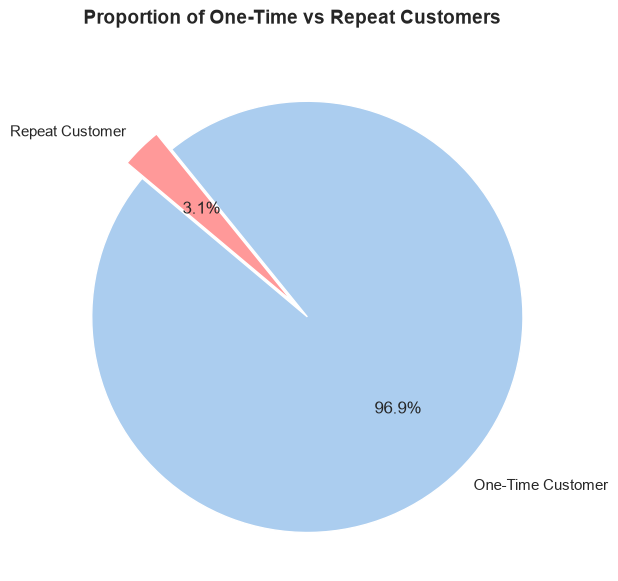

In [12]:
# ==============================================================================
# BLOCK 9: QUESTION 3 & 10 - REPEAT VS ONE-TIME CUSTOMERS
# ==============================================================================

# Counting orders per unique customer ID
customer_orders = merged_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']

# Categorizing customers
customer_orders['segment'] = np.where(customer_orders['total_orders'] > 1, 'Repeat Customer', 'One-Time Customer')

# Counting segments
segment_counts = customer_orders['segment'].value_index if hasattr(customer_orders['segment'], 'value_index') else customer_orders['segment'].value_counts().reset_index()
segment_counts.columns = ['Customer Type', 'Count']

print("=== CUSTOMER RETENTION SUMMARY ===")
print(segment_counts)

# Visualizing via a Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(
    segment_counts['Count'], 
    labels=segment_counts['Customer Type'], 
    autopct='%1.1f%%', 
    colors=['#abcdef', '#ff9999'], 
    startangle=140,
    explode=(0.1, 0)
)
plt.title('Proportion of One-Time vs Repeat Customers', fontsize=14, fontweight='bold')
plt.show()

=== PAYMENT METHODS SUMMARY ===
payment_type  transaction_count  total_payment_value
 credit_card              86769          15589028.22
      boleto              22867           4059699.60
     voucher               6274            405873.03
  debit_card               1691            253533.86


C:\Users\Kanishka\AppData\Local\Temp\ipykernel_8464\3768060879.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


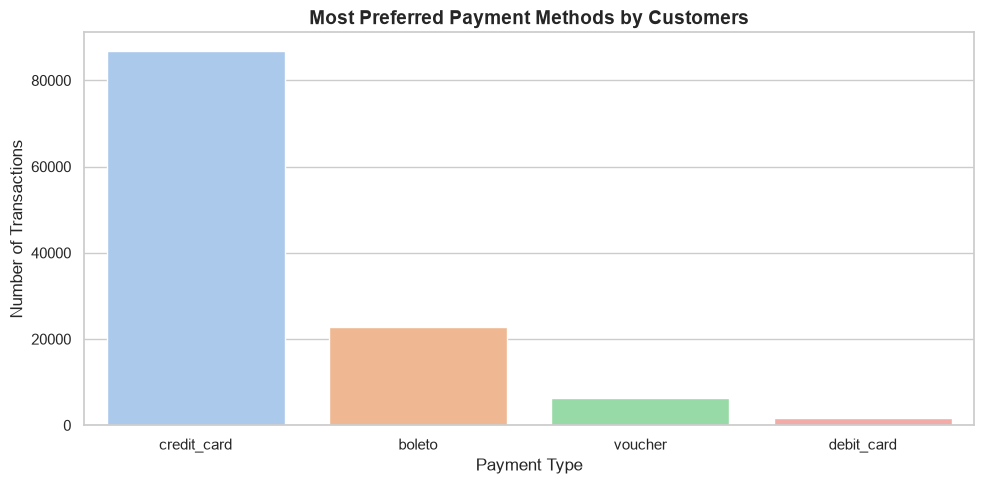

In [13]:
# ==============================================================================
# BLOCK 10: QUESTION 6 - PAYMENT METHODS TREND ANALYSIS
# ==============================================================================

# Grouping by payment type to see transaction counts and total value
payment_analysis = merged_df.groupby('payment_type').agg(
    transaction_count=('order_id', 'count'),
    total_payment_value=('payment_value', 'sum')
).reset_index()

# Sorting by transaction count
payment_analysis = payment_analysis.sort_values(by='transaction_count', ascending=False)

print("=== PAYMENT METHODS SUMMARY ===")
print(payment_analysis.to_string(index=False))

# Visualizing using a Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    x='payment_type', 
    y='transaction_count', 
    data=payment_analysis, 
    palette='pastel'
)
plt.title('Most Preferred Payment Methods by Customers', fontsize=14, fontweight='bold')
plt.xlabel('Payment Type', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# ==============================================================================
# BLOCK 11: BUSINESS INSIGHTS FOR PAYMENT METHODS
# ==============================================================================

print("""
💡 PAYMENT METHOD INSIGHTS:
--------------------------------------------------------------------------------
1. Credit Card Dominance: Credit Cards are the most frequently used payment method, 
   indicating that customers heavily prefer installment plans and transactional 
   convenience.
   
2. Actionable Recommendation: Establishing strategic partnerships with major credit 
   providers to offer targeted cashback and no-cost EMI options can effectively 
   drive up Average Order Values (AOV).
--------------------------------------------------------------------------------
""")


💡 PAYMENT METHOD INSIGHTS:
--------------------------------------------------------------------------------
1. Credit Card Dominance: Credit Cards are the most frequently used payment method, 
   indicating that customers heavily prefer installment plans and transactional 
   convenience.

2. Actionable Recommendation: Establishing strategic partnerships with major credit 
   providers to offer targeted cashback and no-cost EMI options can effectively 
   drive up Average Order Values (AOV).
--------------------------------------------------------------------------------



=== MONTHLY REVENUE TRENDS (SAMPLE) ===
order_month_year  monthly_revenue
         2017-12        770656.15
         2018-01        987151.41
         2018-02        880099.79
         2018-03       1025936.06
         2018-04       1029472.30
         2018-05       1032150.44
         2018-06        909221.10
         2018-07        925302.46
         2018-08        884657.40
         2018-09           145.00


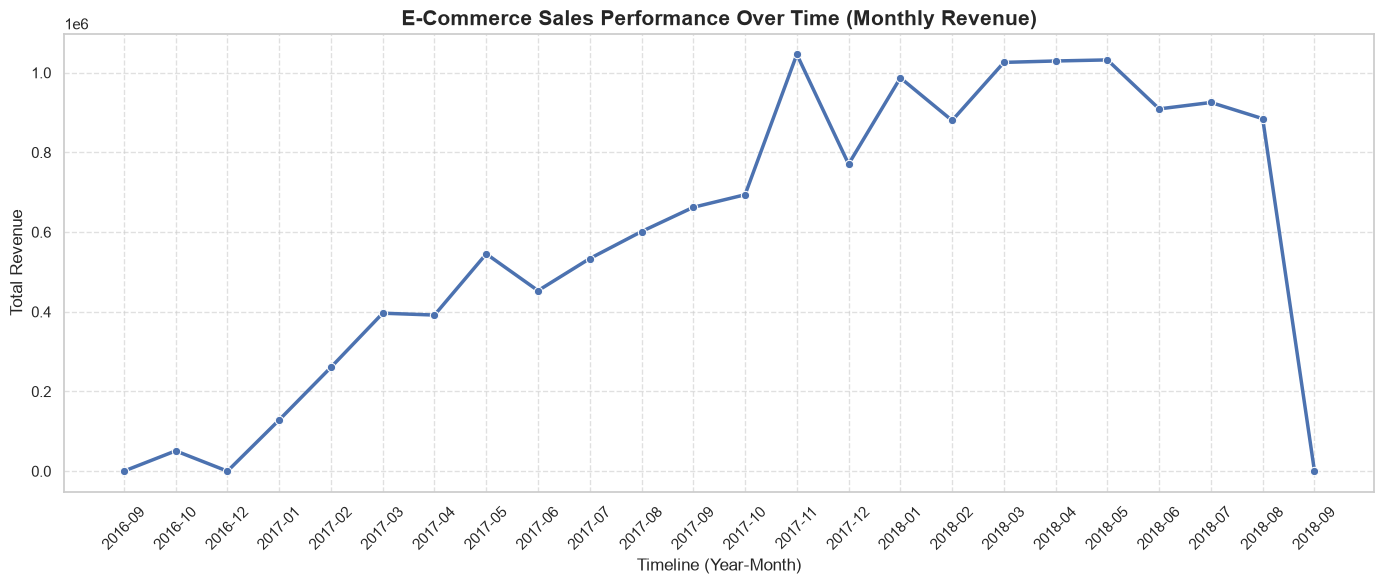

In [15]:
# ==============================================================================
# BLOCK 12: QUESTION 9 - MONTHLY SALES TRENDS (TIME-SERIES)
# ==============================================================================

# Extracting Year-Month from the purchase timestamp
merged_df['order_month_year'] = merged_df['order_purchase_timestamp'].dt.to_period('M')

# Grouping by month to find total sales revenue
monthly_sales = merged_df.groupby('order_month_year').agg(
    monthly_revenue=('price', 'sum')
).reset_index()

# Converting period back to string/datetime for plotting smooth line
monthly_sales['order_month_year'] = monthly_sales['order_month_year'].astype(str)

print("=== MONTHLY REVENUE TRENDS (SAMPLE) ===")
print(monthly_sales.tail(10).to_string(index=False))

# Visualizing using a Line Chart (Step 5 in PDF)
plt.figure(figsize=(14, 6))
sns.lineplot(
    x='order_month_year', 
    y='monthly_revenue', 
    data=monthly_sales, 
    marker='o', 
    color='b', 
    linewidth=2.5
)
plt.title('E-Commerce Sales Performance Over Time (Monthly Revenue)', fontsize=15, fontweight='bold')
plt.xlabel('Timeline (Year-Month)', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# E-Commerce Sales Performance Analysis (Olist Brazilian Dataset)
### Exploratory Data Analysis (EDA) Mini Project

**Project Objective:** To analyze e-commerce sales performance, understand customer behavior, determine revenue-generating categories, and uncover operational bottlenecks.
